# Analisis Tren Media Sosial: **Flu A** (TikTok)
### Tugas: Scraping, Wordcloud, Clustering & Topic Modelling, Social Network Analysis

**Topik:** Flu A
**Periode data:** 1 September 2026 – sekarang
**Sumber data:** TikTok (hasil scraping dengan Apify TikTok Scraper)
**Sumber dataset:** `dataset_tiktok-scraper_2026-09-24_07-24-07-152.csv`

---
Notebook ini berisi:
1. Import Library
2. Load & Inspeksi Data
3. Data Cleaning & Preprocessing
4. Exploratory Data Analysis (EDA)
5. Percobaan 1 — Wordcloud
6. Percobaan 2 — Clustering & Topic Modelling + Visualisasi
7. Percobaan 3 — Social Network Analysis (SNA)
8. Kesimpulan


In [ ]:
# 1. IMPORT LIBRARY
import pandas as pd
import numpy as np
import re
import string
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA, LatentDirichletAllocation
from sklearn.metrics import silhouette_score

import networkx as nx
from itertools import combinations
from collections import Counter

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

print('Semua library berhasil di-import')


Semua library berhasil di-import


## 2. Load & Inspeksi Data

In [ ]:
# Load dataset hasil scraping TikTok
df_raw = pd.read_csv('dataset_tiktok-scraper_2026-09-24_07-24-07-152.csv')
print('Ukuran data awal:', df_raw.shape)
df_raw.head(3)


Ukuran data awal: (486, 363)


,authorMeta/avatar,authorMeta/bioLink,authorMeta/commerceUserInfo/category,authorMeta/commerceUserInfo/categoryButton,authorMeta/commerceUserInfo/commerceUser,authorMeta/commerceUserInfo/downLoadLink/android,authorMeta/commerceUserInfo/downLoadLink/ios,authorMeta/createTime,authorMeta/digg,authorMeta/fans,...,videoMeta/subtitleLinks/1/version,videoMeta/subtitleLinks/2/downloadLink,videoMeta/subtitleLinks/2/language,videoMeta/subtitleLinks/2/source,videoMeta/subtitleLinks/2/sourceUnabbreviated,videoMeta/subtitleLinks/2/tiktokLink,videoMeta/subtitleLinks/2/version,videoMeta/transcriptionLink,videoMeta/width,webVideoUrl
0,https://p16-common-sign.tiktokcdn-us.com/tos-u...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23400,2600000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,576,https://www.tiktok.com/@dr.tommymartin/video/7...
1,https://p16-common-sign.tiktokcdn-us.com/tos-a...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,530,2100000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,576,https://www.tiktok.com/@9news/video/7530380026...
2,https://p16-common-sign.tiktokcdn-us.com/tos-u...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,134,4200000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1280,https://www.tiktok.com/@abc7chicago/video/7688...


In [ ]:
# Ambil kolom-kolom yang relevan untuk analisis topik Flu A
kolom_dipakai = [
    'id', 'text', 'textLanguage', 'createTimeISO', 'searchQuery',
    'authorMeta/name', 'authorMeta/nickName', 'authorMeta/fans',
    'diggCount', 'commentCount', 'shareCount', 'playCount', 'collectCount',
    'webVideoUrl'
]
hashtag_cols = [c for c in df_raw.columns if re.match(r'hashtags/\d+/name', c)]
mention_cols = [c for c in df_raw.columns if re.match(r'mentions/\d+$', c)]

df = df_raw[kolom_dipakai + hashtag_cols + mention_cols].copy()
df['createTimeISO'] = pd.to_datetime(df['createTimeISO'])
print('Jumlah kolom hashtag:', len(hashtag_cols))
print('Jumlah kolom mention:', len(mention_cols))
df.shape


Jumlah kolom hashtag: 27
Jumlah kolom mention: 5


(486, 46)

## 3. Data Cleaning & Preprocessing

Sesuai ketentuan topik **"Flu A (1 September 2026 – sekarang)"**, data difilter terlebih dahulu
berdasarkan rentang waktu tersebut, kemudian dibersihkan (hapus duplikat, hapus baris teks kosong,
dan cleaning teks untuk keperluan text mining).

In [ ]:
# Filter berdasarkan ketentuan topik: 1 September 2026 - sekarang
batas_awal = pd.Timestamp('2026-09-01', tz='UTC')
df = df[df['createTimeISO'] >= batas_awal].reset_index(drop=True)
print('Jumlah data setelah filter tanggal (>= 1 Sept 2026):', df.shape[0])

# Hapus duplikat & baris tanpa teks
df = df.drop_duplicates(subset=['id']).reset_index(drop=True)
df = df.dropna(subset=['text']).reset_index(drop=True)
df = df[df['text'].str.strip() != ''].reset_index(drop=True)
print('Jumlah data setelah hapus duplikat/kosong:', df.shape[0])


Jumlah data setelah filter tanggal (>= 1 Sept 2026): 322
Jumlah data setelah hapus duplikat/kosong: 289


In [ ]:
# Fungsi cleaning teks
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)          # hapus URL
    text = re.sub(r'@[A-Za-z0-9_.]+', ' ', text)             # hapus mention
    text = re.sub(r'#\w+', ' ', text)                        # hapus hashtag (disimpan terpisah)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)                 # hapus angka & simbol
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Stopwords gabungan Indonesia + Inggris (data campuran dua bahasa)
stopwords_id_raw = (
    "yang dan di ke dari untuk dengan pada adalah ini itu atau juga akan telah "
    "sudah saya kamu kita mereka dia nya ku mu tidak tak bukan karena jadi agar supaya jika kalau "
    "lebih sangat banyak sekali paling ada ya aja deh dong sih kok gitu gini yg dgn utk tdk sdh dr "
    "pd yaa nih kan si tuh la loh lho mah nder banget udah gak ga dah bgt aja apa apakah bagaimana "
    "saat waktu masih terus setelah sebelum bisa dapat harus perlu semua tersebut para"
)
stopwords_id = set(stopwords_id_raw.split())

stopwords_en = set([
    'the','a','an','and','or','but','if','of','to','in','on','for','with','is','are','was','were',
    'be','been','being','this','that','these','those','it','its','as','at','by','from','has','have',
    'had','not','no','so','we','you','i','they','he','she','my','your','our','their','will','would',
    'can','could','should','about','into','than','then','there','here','just','more','most','some',
    'what','when','where','who','how','why','do','does','did','get','got','like','one','all','up',
    'out','over','also','via','new','video','tiktok'
])
stopwords_all = stopwords_id.union(stopwords_en)

def remove_stopwords(text):
    tokens = [t for t in text.split() if t not in stopwords_all and len(t) > 2]
    return ' '.join(tokens)

df['text_clean'] = df['text'].apply(clean_text)
df['text_final'] = df['text_clean'].apply(remove_stopwords)
df = df[df['text_final'].str.strip() != ''].reset_index(drop=True)

print('Jumlah data final setelah cleaning:', df.shape[0])
df[['text', 'text_final']].head(5)


Jumlah data final setelah cleaning: 261


,text,text_final
0,As temperatures cool and children return to sc...,temperatures cool children return school healt...
1,"Influenza cases are high this season, especial...",influenza cases high season especially kids ca...
2,Influenza is making many people sick this seas...,influenza making many people sick season learn...
3,The flu is back! #influenza #medicaltiktok #ph...,flu back
4,My mouth and eyes were crusty😭#influenzaa #inf...,mouth eyes crusty


In [ ]:
# Ekstrak daftar hashtag & mention per baris (untuk EDA dan SNA)
def get_hashtags(row):
    tags = [row[c] for c in hashtag_cols if pd.notna(row[c])]
    return [str(t).lower() for t in tags]

def get_mentions(row):
    ments = [row[c] for c in mention_cols if pd.notna(row[c])]
    return [str(m).lower() for m in ments]

df['hashtag_list'] = df.apply(get_hashtags, axis=1)
df['mention_list'] = df.apply(get_mentions, axis=1)
df['n_hashtags'] = df['hashtag_list'].apply(len)
df['n_mentions'] = df['mention_list'].apply(len)

df[['text', 'hashtag_list', 'n_hashtags']].head(5)


,text,hashtag_list,n_hashtags
0,As temperatures cool and children return to sc...,"[flu, covid, vaccines, chicago, news, chicagon...",6
1,"Influenza cases are high this season, especial...","[influenza, pediatrics, health, supportivecare...",5
2,Influenza is making many people sick this seas...,"[influenza, flusymptoms, flutreatment, pediatr...",5
3,The flu is back! #influenza #medicaltiktok #ph...,"[influenza, medicaltiktok, physicianassistant,...",4
4,My mouth and eyes were crusty😭#influenzaa #inf...,"[influenzaa, influenzavirus, influenzanz]",3


## 4. Exploratory Data Analysis (EDA)

In [ ]:
print('=== RINGKASAN DATASET FLU A ===')
print(f"Total postingan (1 Sept 2026 - sekarang): {len(df)}")
print(f"Rentang tanggal: {df['createTimeISO'].min()}  s/d  {df['createTimeISO'].max()}")
print(f"Total engagement (like): {df['diggCount'].sum():,.0f}")
print(f"Total komentar: {df['commentCount'].sum():,.0f}")
print(f"Total views: {df['playCount'].sum():,.0f}")
print(f"Jumlah akun unik yang memposting: {df['authorMeta/name'].nunique()}")


=== RINGKASAN DATASET FLU A ===
Total postingan (1 Sept 2026 - sekarang): 261
Rentang tanggal: 2026-09-02 17:02:30+00:00  s/d  2026-09-24 07:11:41+00:00
Total engagement (like): 41,341,676
Total komentar: 499,604
Total views: 407,076,030
Jumlah akun unik yang memposting: 114


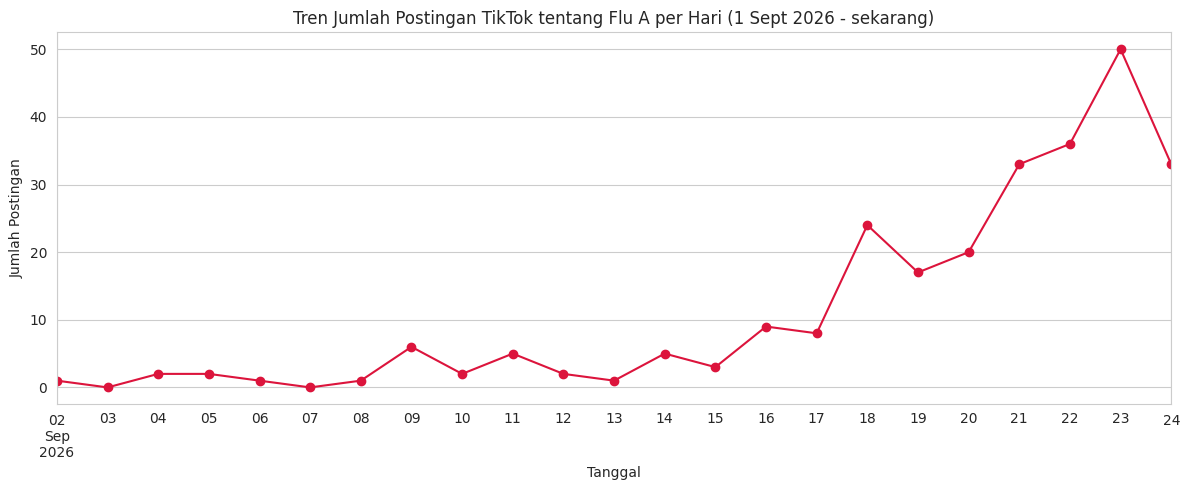

In [ ]:
# Distribusi jumlah postingan per hari
fig, ax = plt.subplots(figsize=(12,5))
df.set_index('createTimeISO').resample('D').size().plot(ax=ax, marker='o', color='crimson')
ax.set_title('Tren Jumlah Postingan TikTok tentang Flu A per Hari (1 Sept 2026 - sekarang)')
ax.set_xlabel('Tanggal')
ax.set_ylabel('Jumlah Postingan')
plt.tight_layout()
plt.savefig('output_01_tren_harian.png', dpi=150)
plt.show()


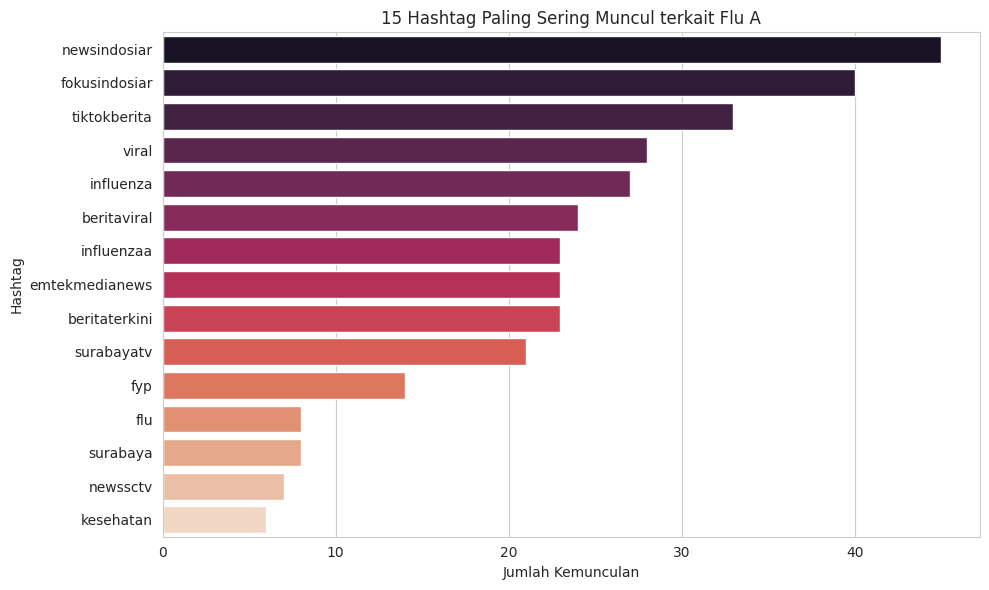

,hashtag,jumlah
0,newsindosiar,45
1,fokusindosiar,40
2,tiktokberita,33
3,viral,28
4,influenza,27
5,beritaviral,24
6,influenzaa,23
7,emtekmedianews,23
8,beritaterkini,23
9,surabayatv,21


In [ ]:
# Top 15 hashtag paling sering muncul
all_hashtags = [h for lst in df['hashtag_list'] for h in lst]
top_hashtags = Counter(all_hashtags).most_common(15)
th_df = pd.DataFrame(top_hashtags, columns=['hashtag','jumlah'])

plt.figure(figsize=(10,6))
sns.barplot(data=th_df, y='hashtag', x='jumlah', hue='hashtag', palette='rocket', legend=False)
plt.title('15 Hashtag Paling Sering Muncul terkait Flu A')
plt.xlabel('Jumlah Kemunculan')
plt.ylabel('Hashtag')
plt.tight_layout()
plt.savefig('output_02_top_hashtag.png', dpi=150)
plt.show()
th_df


## 5. Percobaan 1 — Wordcloud

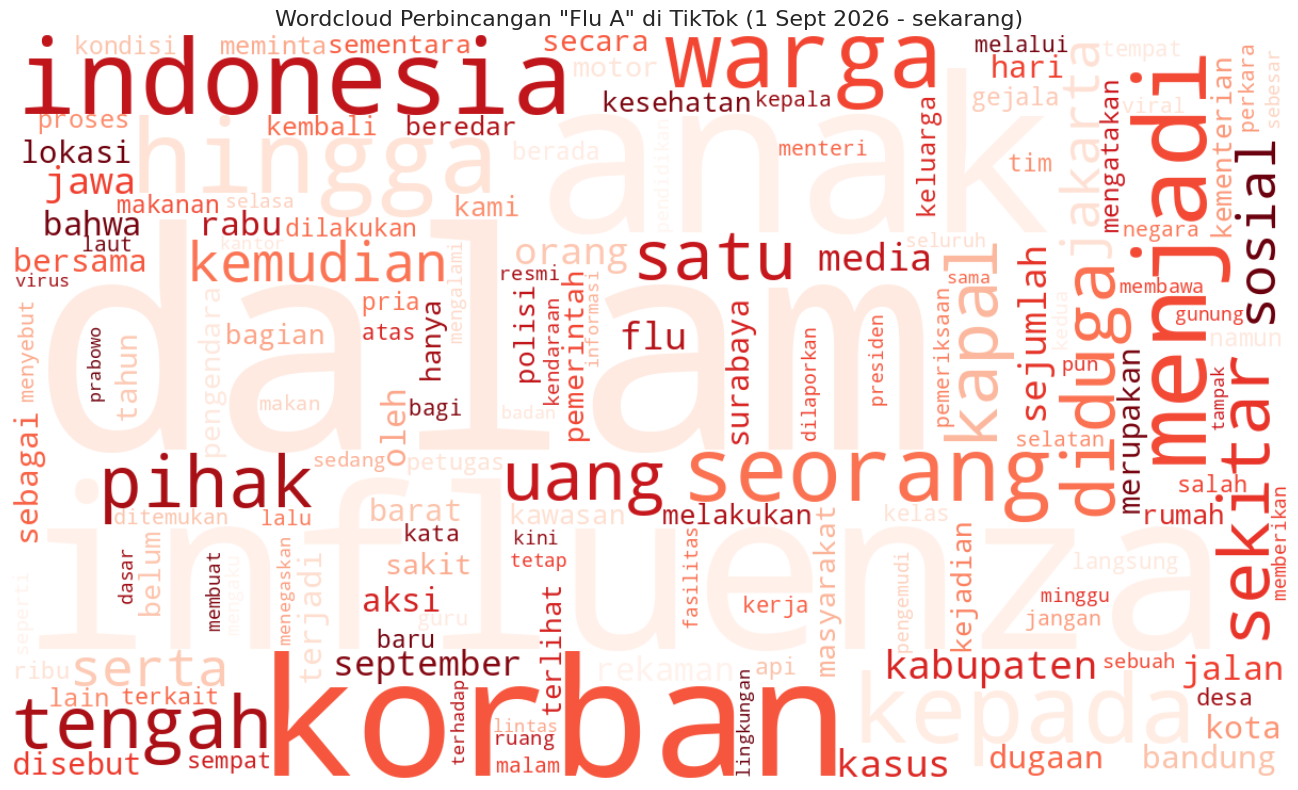

In [ ]:
# Gabungkan seluruh teks yang sudah dibersihkan
all_text = ' '.join(df['text_final'].tolist())

wc = WordCloud(
    width=1200, height=700,
    background_color='white',
    colormap='Reds',
    max_words=150,
    collocations=False
).generate(all_text)

plt.figure(figsize=(14,8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Wordcloud Perbincangan "Flu A" di TikTok (1 Sept 2026 - sekarang)', fontsize=16)
plt.tight_layout()
plt.savefig('output_03_wordcloud.png', dpi=150)
plt.show()


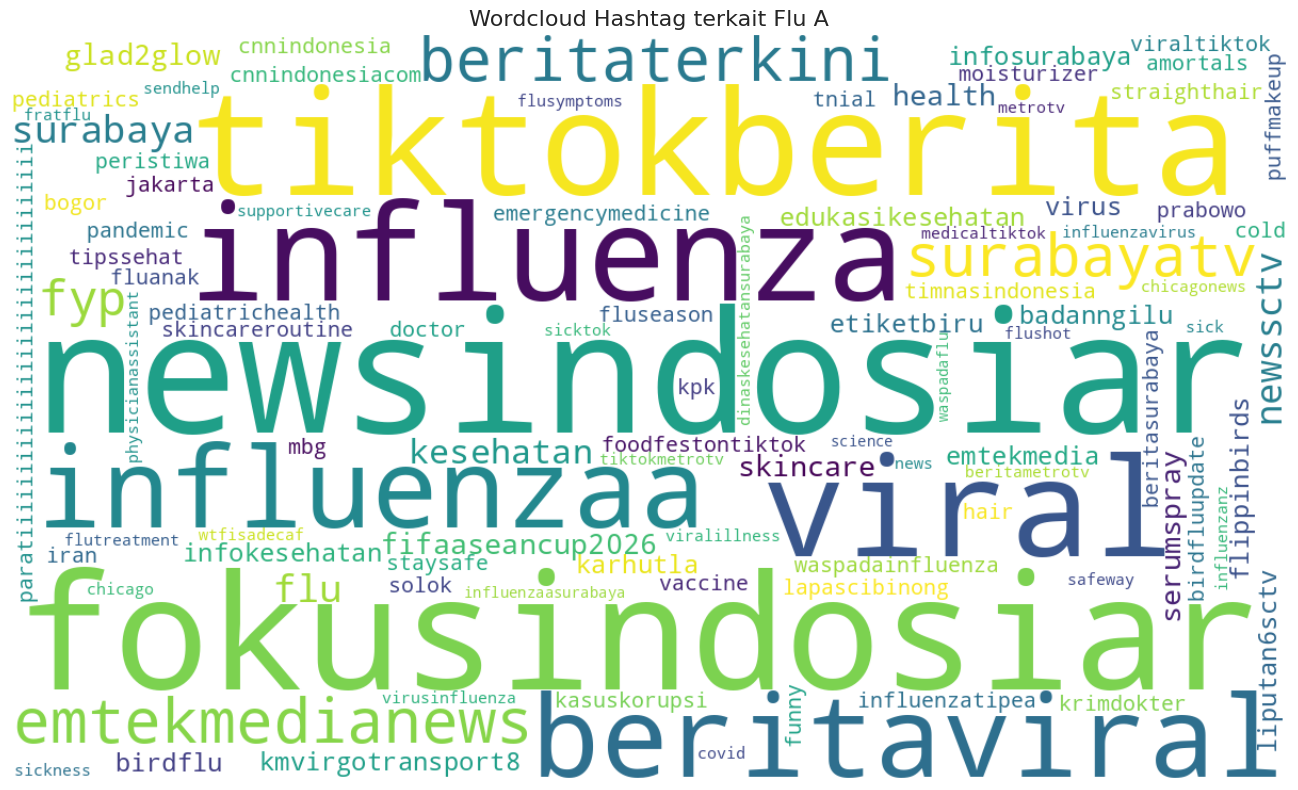

In [ ]:
# Wordcloud khusus dari hashtag (opsional, memberi gambaran topik tambahan)
hashtag_text = ' '.join(all_hashtags)
wc2 = WordCloud(width=1200, height=700, background_color='white', colormap='viridis',
                max_words=100, collocations=False).generate(hashtag_text)

plt.figure(figsize=(14,8))
plt.imshow(wc2, interpolation='bilinear')
plt.axis('off')
plt.title('Wordcloud Hashtag terkait Flu A', fontsize=16)
plt.tight_layout()
plt.savefig('output_04_wordcloud_hashtag.png', dpi=150)
plt.show()


## 6. Percobaan 2 — Clustering & Topic Modelling

Tahapan:
1. **TF-IDF Vectorization** dari teks yang sudah dibersihkan
2. **K-Means Clustering** untuk mengelompokkan postingan yang mirip topiknya
3. **Topic Modelling (LDA - Latent Dirichlet Allocation)** untuk menemukan tema/topik tersembunyi
4. **Visualisasi** hasil clustering (PCA 2D) dan kata kunci tiap topik

In [ ]:
# 6.1 TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=500, min_df=2, max_df=0.9)
X_tfidf = tfidf.fit_transform(df['text_final'])
print('Bentuk matriks TF-IDF:', X_tfidf.shape)


Bentuk matriks TF-IDF: (261, 500)


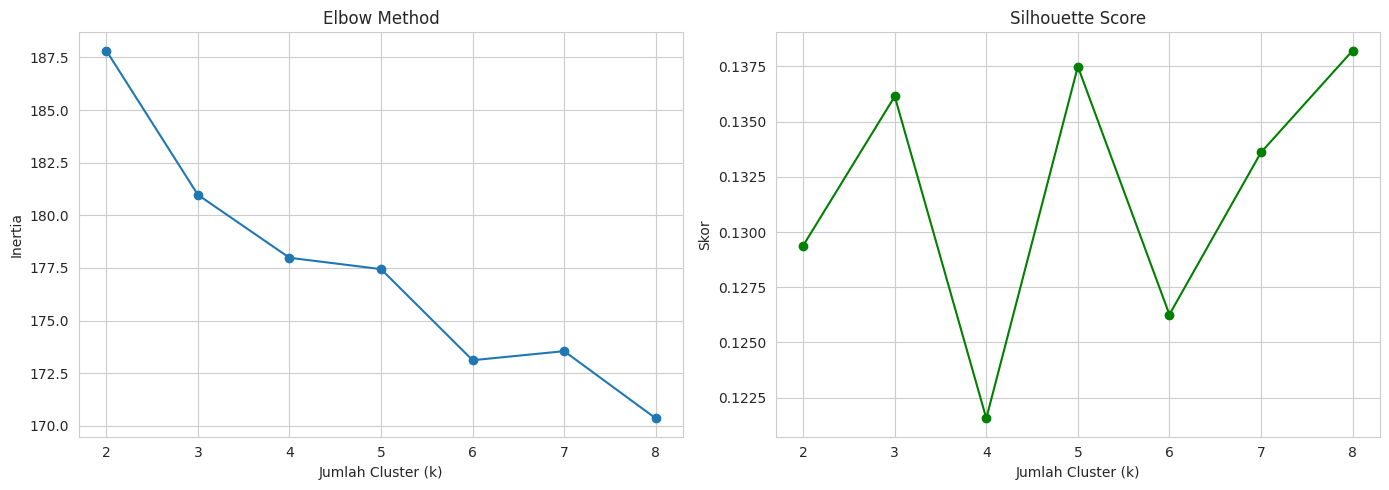

Jumlah cluster terbaik berdasarkan Silhouette Score: 8


In [ ]:
# 6.2 Menentukan jumlah cluster optimal dengan Elbow Method & Silhouette Score
inertias, sil_scores = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_tfidf)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_tfidf, labels))

fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].plot(list(K_range), inertias, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Jumlah Cluster (k)'); axes[0].set_ylabel('Inertia')

axes[1].plot(list(K_range), sil_scores, marker='o', color='green')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Jumlah Cluster (k)'); axes[1].set_ylabel('Skor')
plt.tight_layout()
plt.savefig('output_05_elbow_silhouette.png', dpi=150)
plt.show()

best_k = list(K_range)[int(np.argmax(sil_scores))]
print('Jumlah cluster terbaik berdasarkan Silhouette Score:', best_k)


In [ ]:
# 6.3 K-Means Clustering dengan k terbaik
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_tfidf)

print(df['cluster'].value_counts().sort_index())

# Kata kunci teratas tiap cluster
terms = tfidf.get_feature_names_out()
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]
for i in range(best_k):
    top_terms = [terms[ind] for ind in order_centroids[i, :10]]
    print(f"\nCluster {i} (n={sum(df['cluster']==i)}): {', '.join(top_terms)}")


cluster
0      3
1    205
2      2
3      3
4     27
5     13
6      2
7      6
Name: count, dtype: int64

Cluster 0 (n=3): kapal, tahun, menabrak, sama, arah, kamis, jalur, barat, kedua, berukuran

Cluster 1 (n=205): dalam, warga, hari, jakarta, satu, indonesia, jawa, kabupaten, anak, menjadi

Cluster 2 (n=2): sama, batuk, kalimantan, kamera, kami, kamis, kantor, kapal, karhutla, kartu

Cluster 3 (n=3): asean, fifa, cup, indonesia, sepak, bola, berlangsung, september, jakarta, tiba

Cluster 4 (n=27): influenza, gejala, kasus, kenali, surabaya, stay, tipe, kesehatan, virus, anak

Cluster 5 (n=13): flu, season, update, stay, area, virus, hari, influenza, kebakaran, kawasan

Cluster 6 (n=2): yusron, imanuddin, bukti, seksual, rekaman, kepada, dugaan, kekerasan, disebut, diduga

Cluster 7 (n=6): korban, penyelam, kapal, virgo, basarnas, jasad, tim, dalam, laut, pencarian


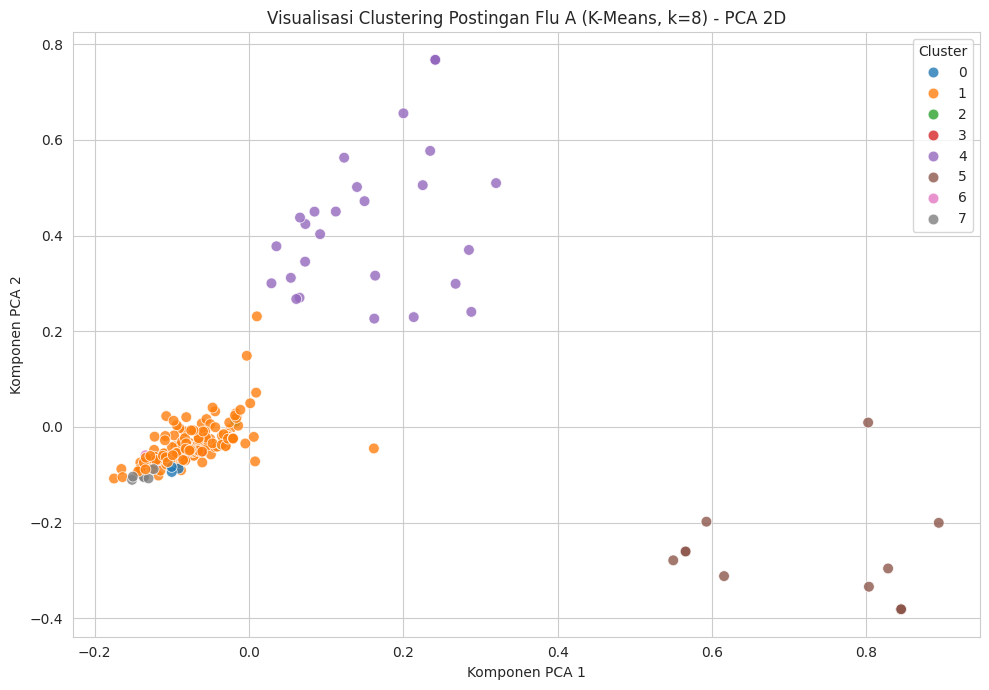

In [ ]:
# 6.4 Visualisasi Cluster dengan PCA (reduksi ke 2 dimensi)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_tfidf.toarray())
df['pca_x'], df['pca_y'] = X_pca[:,0], X_pca[:,1]

plt.figure(figsize=(10,7))
sns.scatterplot(data=df, x='pca_x', y='pca_y', hue='cluster', palette='tab10', s=60, alpha=0.8)
plt.title(f'Visualisasi Clustering Postingan Flu A (K-Means, k={best_k}) - PCA 2D')
plt.xlabel('Komponen PCA 1'); plt.ylabel('Komponen PCA 2')
plt.legend(title='Cluster')
plt.tight_layout()
plt.savefig('output_06_cluster_pca.png', dpi=150)
plt.show()


In [ ]:
# 6.5 Topic Modelling dengan LDA
count_vec = CountVectorizer(max_features=500, min_df=2, max_df=0.9)
X_count = count_vec.fit_transform(df['text_final'])

n_topics = best_k
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42, max_iter=20)
lda_topics = lda.fit_transform(X_count)
df['topic_lda'] = lda_topics.argmax(axis=1)

feature_names = count_vec.get_feature_names_out()
print('=== TOPIK HASIL LDA ===')
for idx, topic in enumerate(lda.components_):
    top_words = [feature_names[i] for i in topic.argsort()[-10:][::-1]]
    print(f"Topik {idx}: {', '.join(top_words)}")


=== TOPIK HASIL LDA ===
Topik 0: dalam, korban, kapal, tim, makanan, proses, penyelam, virgo, imigrasi, hingga
Topik 1: flu, dalam, indonesia, oleh, pemerintah, prabowo, jakarta, hingga, lalu, presiden
Topik 2: indonesia, dalam, tahun, negara, pendidikan, gubernur, sebesar, menteri, september, kkri
Topik 3: resmi, uang, warga, minggu, hari, korban, malam, petugas, lokasi, pihak
Topik 4: influenza, anak, uang, kesehatan, sakit, bandung, jangan, kasus, flu, virus
Topik 5: anak, kapal, gunung, menjadi, krakatau, desa, dalam, daratan, kereta, seorang
Topik 6: kemudian, dalam, motor, pengendara, diduga, seorang, terjadi, kejadian, menjadi, jalan
Topik 7: warga, dalam, polisi, dugaan, korban, diduga, orang, satu, fasilitas, kepada


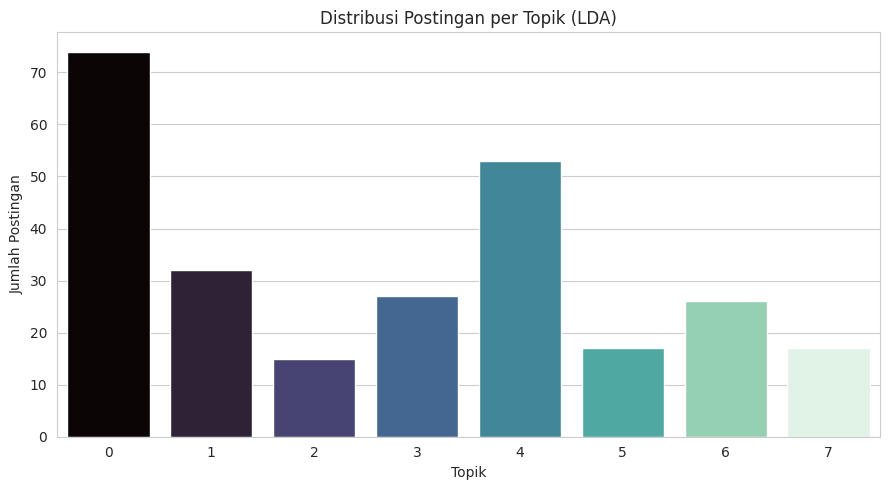

In [ ]:
# 6.6 Visualisasi distribusi topik LDA
plt.figure(figsize=(9,5))
sns.countplot(data=df, x='topic_lda', hue='topic_lda', palette='mako', legend=False)
plt.title('Distribusi Postingan per Topik (LDA)')
plt.xlabel('Topik'); plt.ylabel('Jumlah Postingan')
plt.tight_layout()
plt.savefig('output_07_lda_distribution.png', dpi=150)
plt.show()


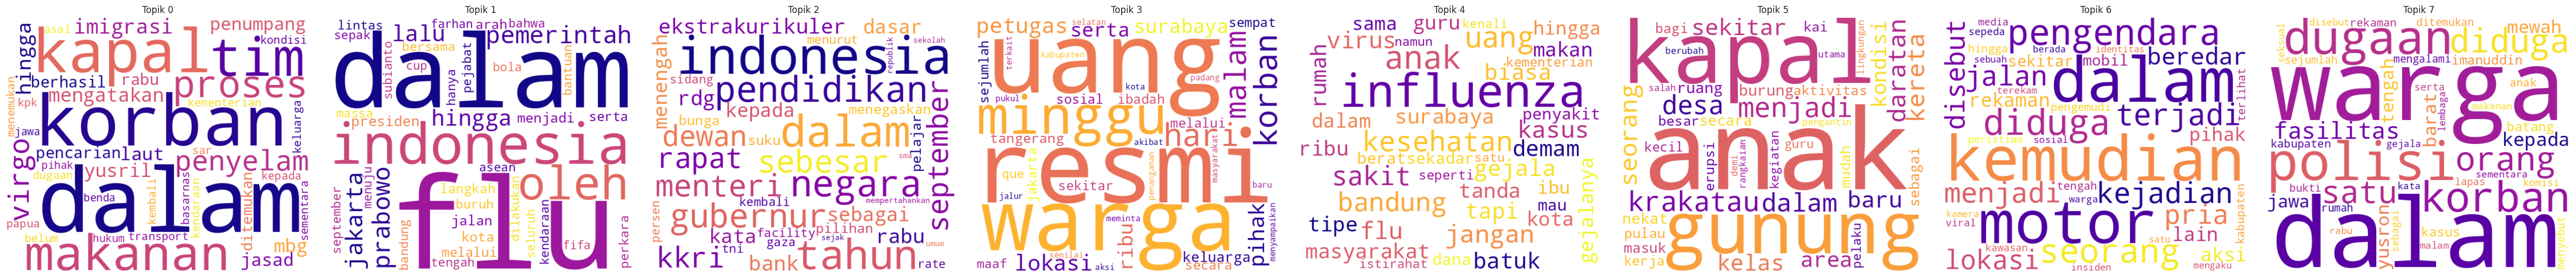

In [ ]:
# 6.7 Wordcloud per topik LDA (memperjelas tema tiap topik)
fig, axes = plt.subplots(1, n_topics, figsize=(6*n_topics, 5))
if n_topics == 1: axes = [axes]
for idx, topic in enumerate(lda.components_):
    word_freq = {feature_names[i]: topic[i] for i in topic.argsort()[-40:]}
    wc_topic = WordCloud(width=600, height=500, background_color='white',
                          colormap='plasma', collocations=False).generate_from_frequencies(word_freq)
    axes[idx].imshow(wc_topic, interpolation='bilinear')
    axes[idx].set_title(f'Topik {idx}')
    axes[idx].axis('off')
plt.tight_layout()
plt.savefig('output_08_wordcloud_per_topik.png', dpi=150)
plt.show()


## 7. Percobaan 3 — Social Network Analysis (SNA)

Karena data mention (`@akun`) pada dataset relatif sedikit, jaringan sosial dibangun dari
**co-occurrence hashtag** (dua hashtag dianggap terhubung bila muncul bersama dalam satu postingan)
serta **jaringan author–mention** dari data yang tersedia. Pendekatan co-occurrence hashtag umum
digunakan dalam SNA media sosial untuk melihat kedekatan/klaster isu.

In [ ]:
# 7.1 Bangun jaringan CO-OCCURRENCE HASHTAG
G_hashtag = nx.Graph()
edge_counter = Counter()

for tags in df['hashtag_list']:
    tags = list(set(tags))
    if len(tags) < 2:
        continue
    for a, b in combinations(sorted(tags), 2):
        edge_counter[(a,b)] += 1

for (a,b), w in edge_counter.items():
    G_hashtag.add_edge(a, b, weight=w)

print('Jumlah node (hashtag):', G_hashtag.number_of_nodes())
print('Jumlah edge (relasi antar-hashtag):', G_hashtag.number_of_edges())


Jumlah node (hashtag): 356
Jumlah edge (relasi antar-hashtag): 958


In [ ]:
# 7.2 Ambil subgraph dari hashtag paling berpengaruh saja (agar visual terbaca)
top_n_nodes = [h for h,_ in Counter(all_hashtags).most_common(30)]
G_sub = G_hashtag.subgraph(top_n_nodes).copy()

# Hitung centrality untuk melihat hashtag paling sentral/berpengaruh
degree_cent = nx.degree_centrality(G_sub)
betw_cent = nx.betweenness_centrality(G_sub, weight='weight')

centrality_df = pd.DataFrame({
    'hashtag': list(degree_cent.keys()),
    'degree_centrality': list(degree_cent.values()),
    'betweenness_centrality': [betw_cent[k] for k in degree_cent.keys()]
}).sort_values('degree_centrality', ascending=False)

print('=== Top 10 Hashtag Paling Sentral dalam Jaringan ===')
centrality_df.head(10)


=== Top 10 Hashtag Paling Sentral dalam Jaringan ===


,hashtag,degree_centrality,betweenness_centrality
7,influenza,0.482759,0.302864
4,viral,0.413793,0.265354
6,kesehatan,0.344828,0.208732
23,influenzaa,0.310345,0.044896
19,newsindosiar,0.275862,0.000000
0,surabaya,0.275862,0.067135
25,beritaviral,0.241379,0.012644
24,emtekmedianews,0.241379,0.110685
12,flu,0.241379,0.013361
26,tiktokberita,0.241379,0.014984


In [ ]:
# 7.3 Deteksi komunitas (cluster) dalam jaringan hashtag
from networkx.algorithms import community
communities = community.greedy_modularity_communities(G_sub, weight='weight')
print(f'Jumlah komunitas terdeteksi: {len(communities)}')
for i, com in enumerate(communities):
    print(f"Komunitas {i}: {', '.join(list(com)[:10])}")

node_community = {}
for i, com in enumerate(communities):
    for node in com:
        node_community[node] = i


Jumlah komunitas terdeteksi: 4
Komunitas 0: surabaya, kesehatan, fyp, influenzaa, influenza, health, infokesehatan, edukasikesehatan, infosurabaya, birdflu
Komunitas 1: fifaaseancup2026, newssctv, fokusindosiar, karhutla, emtekmedianews, emtekmedia, newsindosiar, liputan6sctv
Komunitas 2: tiktokberita, viral, beritaterkini, surabayatv, beritaviral
Komunitas 3: serumspray, glad2glow, skincare


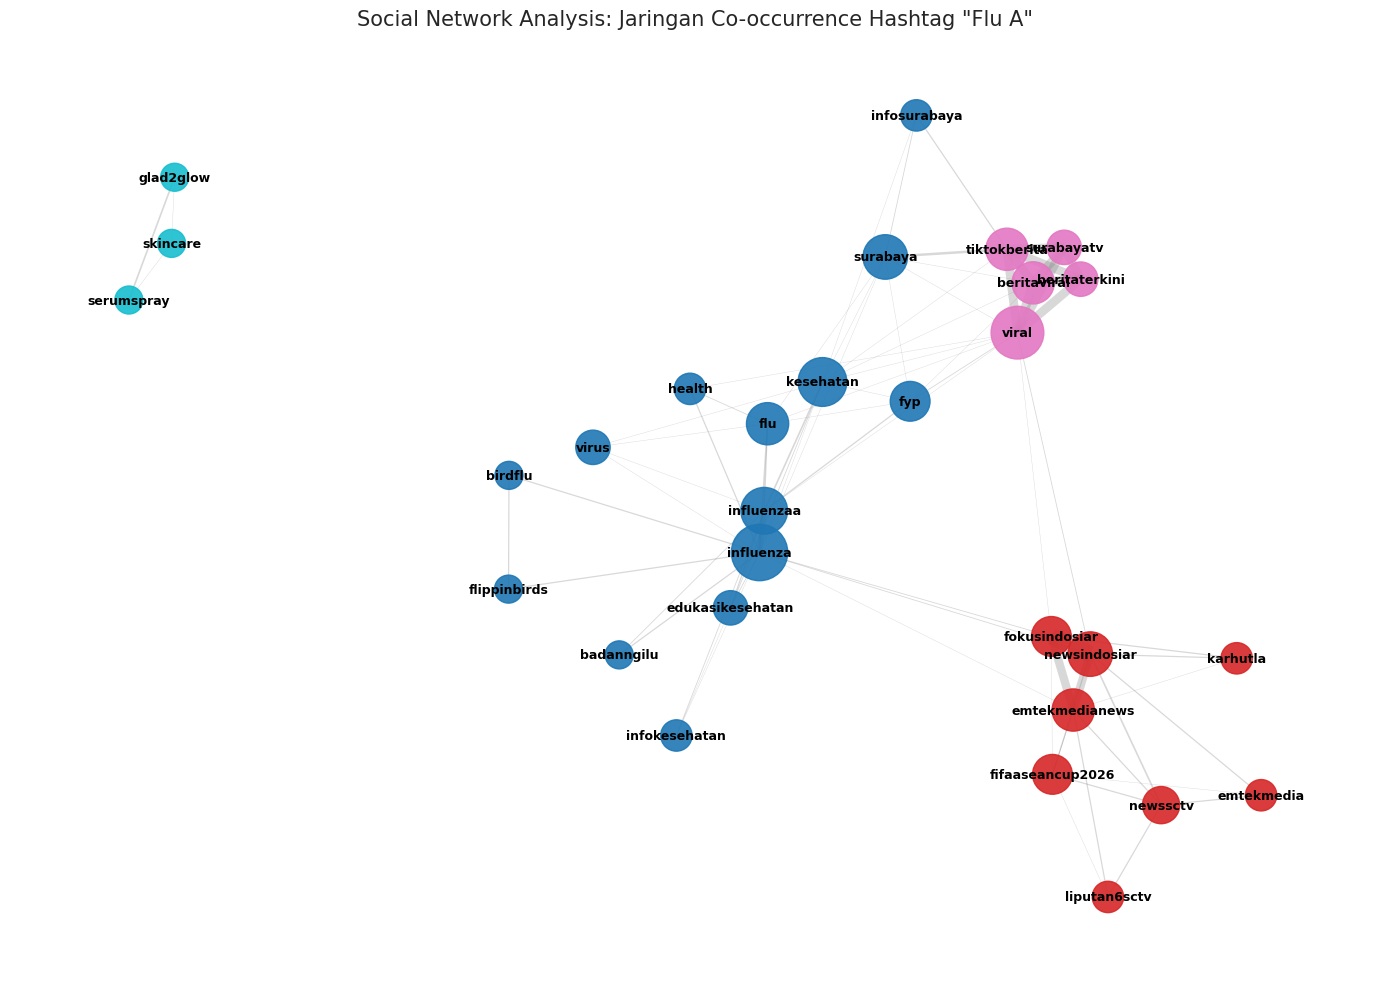

In [ ]:
# 7.4 Visualisasi jaringan hashtag (Social Network Analysis)
plt.figure(figsize=(14,10))
pos = nx.spring_layout(G_sub, k=0.6, seed=42, weight='weight')

node_sizes = [3000*degree_cent[n] + 200 for n in G_sub.nodes()]
node_colors = [node_community.get(n, 0) for n in G_sub.nodes()]
edge_weights = [G_sub[u][v]['weight']*0.3 for u,v in G_sub.edges()]

nx.draw_networkx_nodes(G_sub, pos, node_size=node_sizes, node_color=node_colors,
                        cmap='tab10', alpha=0.9)
nx.draw_networkx_edges(G_sub, pos, width=edge_weights, alpha=0.3, edge_color='gray')
nx.draw_networkx_labels(G_sub, pos, font_size=9, font_weight='bold')

plt.title('Social Network Analysis: Jaringan Co-occurrence Hashtag "Flu A"', fontsize=15)
plt.axis('off')
plt.tight_layout()
plt.savefig('output_09_sna_hashtag_network.png', dpi=150)
plt.show()


Jumlah relasi author->mention yang ditemukan: 19


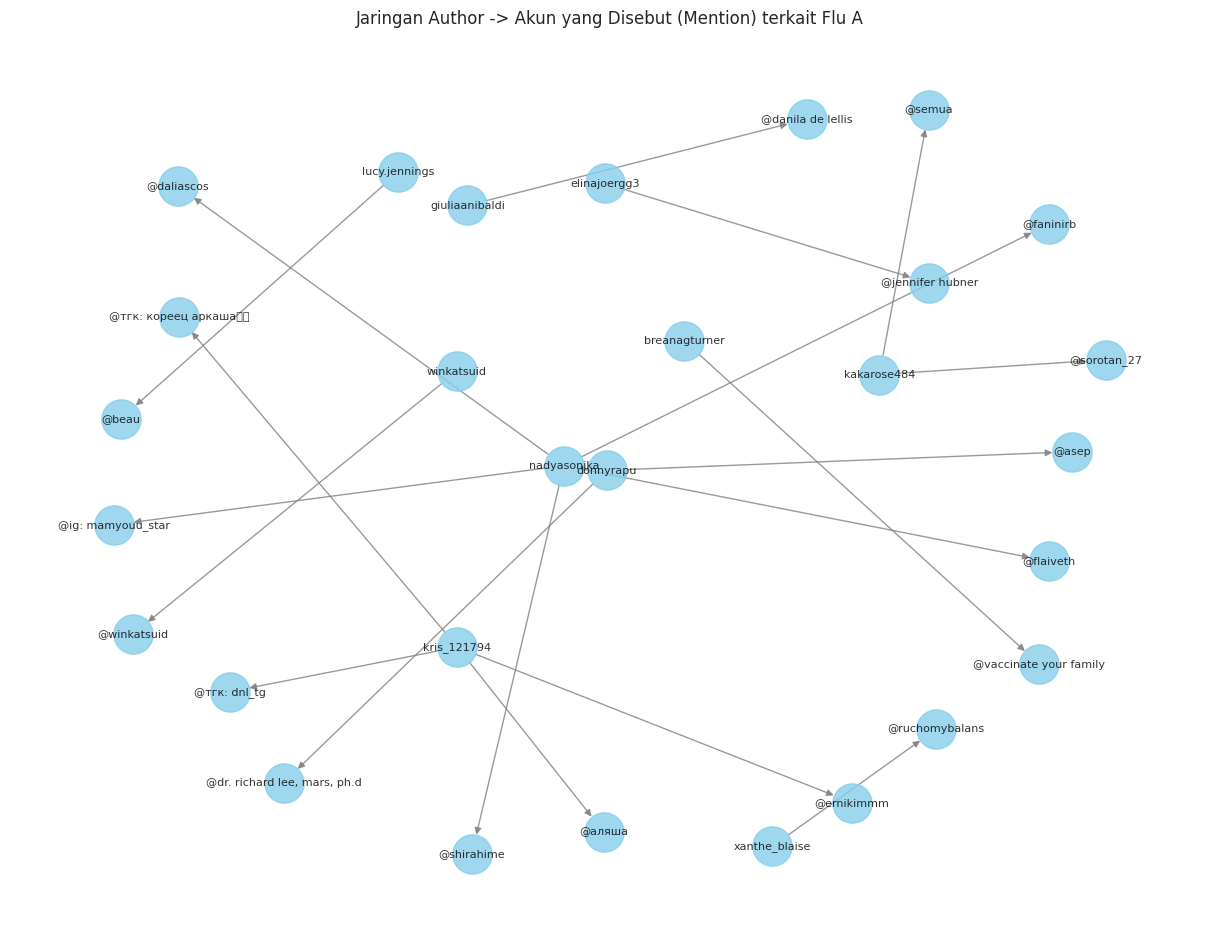

In [ ]:
# 7.5 (Tambahan) Jaringan Author - Mention, jika data mention tersedia
G_mention = nx.DiGraph()
mention_rows = df[df['n_mentions'] > 0]

for _, row in mention_rows.iterrows():
    author = row['authorMeta/name']
    for m in row['mention_list']:
        G_mention.add_edge(author, m)

print('Jumlah relasi author->mention yang ditemukan:', G_mention.number_of_edges())

if G_mention.number_of_edges() > 0:
    plt.figure(figsize=(12,9))
    pos2 = nx.spring_layout(G_mention, k=0.8, seed=42)
    nx.draw(G_mention, pos2, with_labels=True, node_color='skyblue', node_size=800,
            font_size=8, arrows=True, edge_color='gray', alpha=0.8)
    plt.title('Jaringan Author -> Akun yang Disebut (Mention) terkait Flu A')
    plt.tight_layout()
    plt.savefig('output_10_sna_mention_network.png', dpi=150)
    plt.show()
else:
    print('Data mention terlalu sedikit untuk divisualisasikan sebagai jaringan terpisah;')
    print('analisis SNA utama menggunakan jaringan co-occurrence hashtag di atas.')


## 8. Kesimpulan

Ringkasan hasil analisis akan disimpulkan di sini berdasarkan output di atas, mencakup:
- **Wordcloud**: kata dan hashtag yang paling dominan dalam perbincangan tentang Flu A di TikTok.
- **Clustering & Topic Modelling**: jumlah dan tema topik utama yang muncul dari K-Means dan LDA.
- **Social Network Analysis**: hashtag/isu paling sentral serta komunitas/klaster topik yang terbentuk
  dari jaringan co-occurrence hashtag.

*(Silakan lengkapi bagian ini secara naratif sesuai temuan aktual saat notebook dijalankan, lalu
pindahkan ke dalam laporan sesuai template yang diberikan dosen.)*